In [1]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine(
    "",
    connect_args={"sslmode": "require"}
)

In [2]:
df = pd.read_sql(
    'SELECT * FROM "TotalEmissionCO2s";',
    engine
)
df

,Id,Year,Value
0,1,2003,11687.26
1,2,2004,11530.77
2,3,2005,12201.48
3,4,2006,11311.10
4,5,2007,11891.77
5,6,2008,11998.70
6,7,2009,11459.89
7,8,2010,11343.31
8,9,2011,12485.41
9,10,2012,11943.77


In [16]:
X = df[["Year"]].values
y = df["Value"].values
future_years = pd.DataFrame({"Year": [2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029]})

In [17]:
import os
os.makedirs("../models/TotalEmissionCO2s", exist_ok=True)

In [18]:
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.linear_model import Ridge
import joblib

loo = LeaveOneOut()
ridge = Ridge()
param_grid = {
    "alpha": [0.01, 0.1, 1, 10],
    "fit_intercept": [True, False],
    "solver": ['auto', 'svd', 'cholesky', 'lsqr']
}


grid = GridSearchCV(ridge, param_grid, cv=loo, scoring='neg_mean_squared_error')
grid.fit(X, y)

best_model = grid.best_estimator_

joblib.dump(best_model, "../models/TotalEmissionCO2s/ridge_total_emission_model.pkl")

y_forecast = best_model.predict(future_years[["Year"]].values)
df_forecast = pd.DataFrame({"Year": future_years["Year"], "Value": y_forecast})
df_forecast


,Year,Value
0,2020,10519.141789
1,2021,10431.334014
2,2022,10343.526238
3,2023,10255.718463
4,2024,10167.910688
5,2025,10080.102913
6,2026,9992.295138
7,2027,9904.487363
8,2028,9816.679588
9,2029,9728.871813


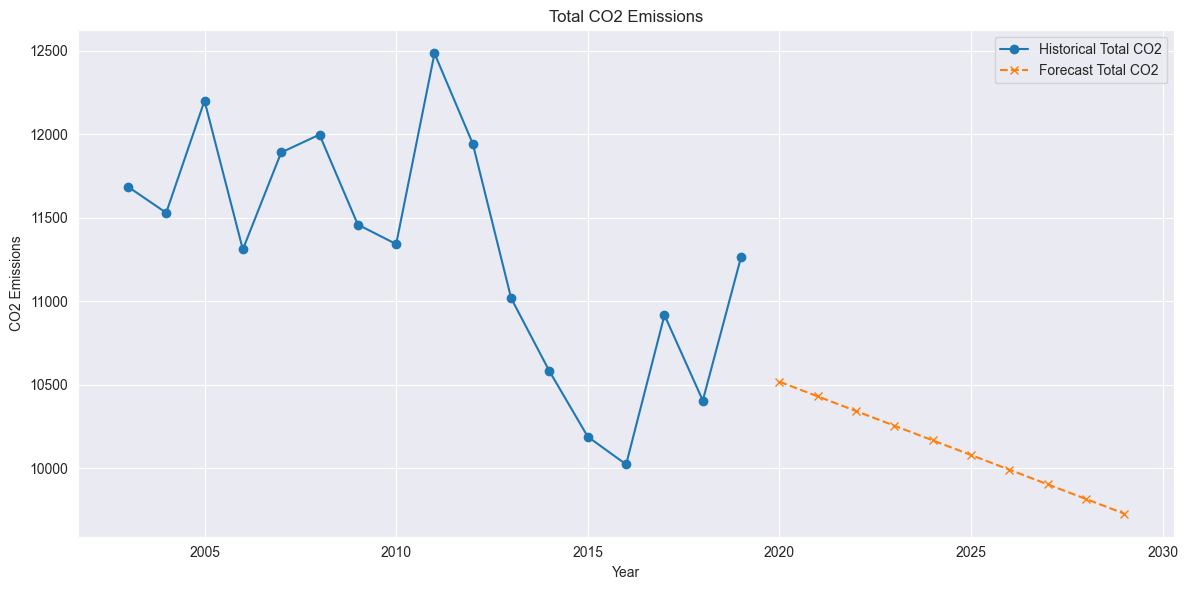

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df["Year"], df["Value"], marker='o', label="Historical Total CO2")
plt.plot(df_forecast["Year"], df_forecast["Value"], marker='x', linestyle='--', label="Forecast Total CO2")

plt.title("Total CO2 Emissions")
plt.xlabel("Year")
plt.ylabel("CO2 Emissions")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
